**Name**:Sameer Gupta

**Roll No**:252010036

# Digit Dataset Analysis (MNIST)
This notebook contains solutions to 25 specific questions regarding the MNIST digit dataset.

In [1]:
# 1. Digit dataset
# Load the digit dataset and report the number of samples and features.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load data (MNIST 784)
# Note: This downloads ~70MB of data. parser='auto' is more efficient.
mnist = fetch_openml('mnist_784', version=1, parser='auto', cache=False)

X = mnist.data
y = mnist.target.astype(int)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Number of samples: 70000
Number of features: 784


In [2]:
# 2. What is the shape of each image? How many pixels does each image contain?

img_shape = (28, 28)
total_pixels = img_shape[0] * img_shape[1]

print(f"Shape of each image: {img_shape}")
print(f"Pixels per image: {total_pixels}")

Shape of each image: (28, 28)
Pixels per image: 784


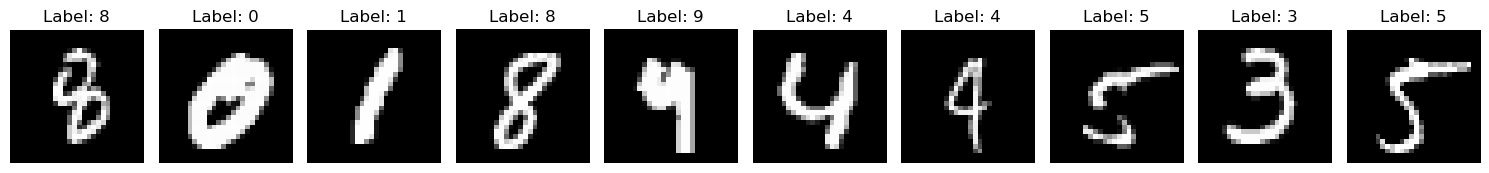

In [3]:
# 3. Display 10 random digit images with their labels.

fig, axes = plt.subplots(1, 10, figsize=(15, 3))
random_indices = np.random.choice(X.index, 10, replace=False)

for ax, idx in zip(axes, random_indices):
    image = X.loc[idx].values.reshape(28, 28)
    label = y.loc[idx]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 4. Check the datatype of features and target. Are they numeric or categorical?

print("Features Data Type:", X.dtypes.iloc[0])
print("Target Data Type:", y.dtypes)
print("\nInterpretation:")
print("Features are numeric (integers representing pixel intensity).")
print("Target is categorical (representing digit classes 0-9), though often stored as integers.")

Features Data Type: int64
Target Data Type: int64

Interpretation:
Features are numeric (integers representing pixel intensity).
Target is categorical (representing digit classes 0-9), though often stored as integers.


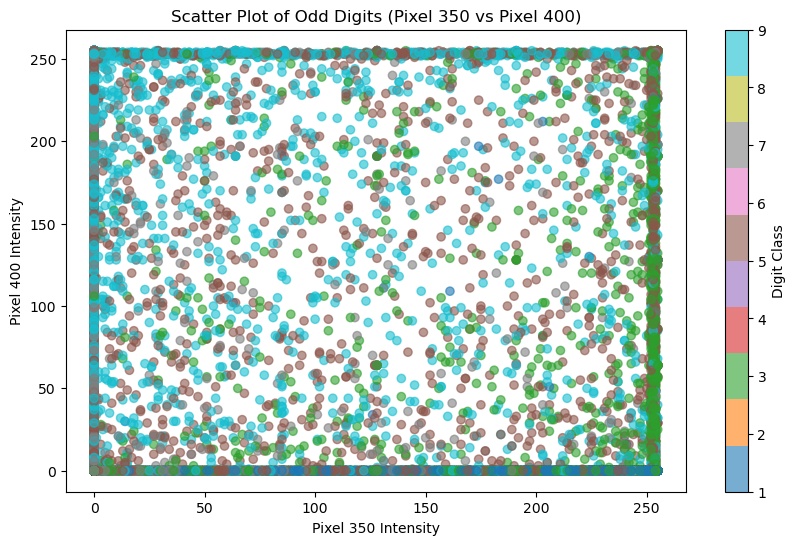

In [5]:
# 5. Create a sub database of only odd digits. Create a scatter plot colored by digit class.
# Note: Since the data is 784-dimensional, we plot two central pixels (pixel_350 vs pixel_400) to visualize.

odd_digits = X[y % 2 != 0].copy()
odd_labels = y[y % 2 != 0]

plt.figure(figsize=(10, 6))
# Using pixel_350 and pixel_400 as arbitrary dimensions for simple scatter
plt.scatter(odd_digits.iloc[:, 350], odd_digits.iloc[:, 400], c=odd_labels, cmap='tab10', alpha=0.6)
plt.colorbar(label='Digit Class')
plt.title('Scatter Plot of Odd Digits (Pixel 350 vs Pixel 400)')
plt.xlabel('Pixel 350 Intensity')
plt.ylabel('Pixel 400 Intensity')
plt.show()

In [6]:
# 6. Identify the digit class with the highest and lowest number of samples.

counts = y.value_counts()
print(f"Digit with HIGHEST samples: {counts.idxmax()} (Count: {counts.max()})")
print(f"Digit with LOWEST samples: {counts.idxmin()} (Count: {counts.min()})")

Digit with HIGHEST samples: 1 (Count: 7877)
Digit with LOWEST samples: 5 (Count: 6313)


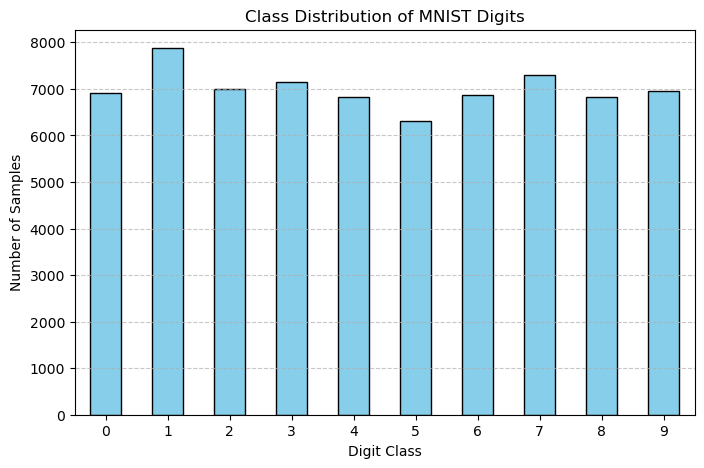

In [7]:
# 7. Visualize class distribution using a bar chart.

plt.figure(figsize=(8, 5))
counts.sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution of MNIST Digits')
plt.xlabel('Digit Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 8. If the dataset is balanced, explain why that is beneficial for classification.

**Answer:**
The MNIST dataset is relatively balanced (as seen in the bar chart, all classes have around 6,000-7,000 samples). 

A balanced dataset is beneficial because:
1. **Bias Prevention:** It prevents the model from becoming biased toward the majority class. In an imbalanced dataset, a model might achieve high accuracy simply by always predicting the frequent class, ignoring the minority classes.
2. **Metric Reliability:** Standard evaluation metrics like Accuracy are valid. In imbalanced data, Accuracy can be misleading, requiring metrics like F1-score or AUC-ROC.
3. **Gradient Updates:** During training (e.g., Neural Networks), the model receives gradients from all classes equally, ensuring it learns features for every digit effectively.

In [8]:
# 9. Create a dataset containing 50 samples from digits divisible by 3.
# Digits divisible by 3 are: 0, 3, 6, 9.

div_by_3_mask = y.isin([0, 3, 6, 9])
subset_div_3 = X[div_by_3_mask].sample(50, random_state=42)
subset_labels = y.loc[subset_div_3.index]

print(f"Subset shape: {subset_div_3.shape}")
print("Sample labels in subset:", subset_labels.values[:10])

Subset shape: (50, 784)
Sample labels in subset: [0 3 9 9 6 0 3 6 6 0]


In [9]:
# 10. Compute the minimum, maximum, and mean pixel intensity across the dataset.

min_val = X.min().min()
max_val = X.max().max()
mean_val = X.mean().mean()

print(f"Minimum Pixel Intensity: {min_val}")
print(f"Maximum Pixel Intensity: {max_val}")
print(f"Mean Pixel Intensity: {mean_val:.2f}")

Minimum Pixel Intensity: 0
Maximum Pixel Intensity: 255
Mean Pixel Intensity: 33.39


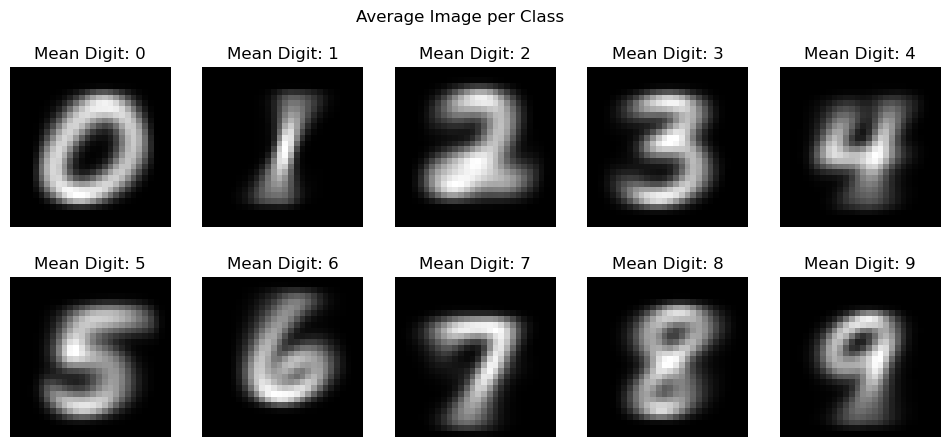

In [10]:
# 11. Calculate the average image for each digit (mean image per class). Plot these mean as a graph.

mean_images = X.groupby(y).mean()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    if idx < 10:
        # Get the mean image for digit 'idx'
        img = mean_images.loc[idx].values.reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Mean Digit: {idx}")
        ax.axis('off')
plt.suptitle("Average Image per Class")
plt.show()

In [11]:
# 12. Identify pixels that have near-zero variance across all samples.
# 'Near-zero' is defined here as variance == 0 (pixels that are always white/black, usually corners).

pixel_variances = X.var()
zero_var_pixels = pixel_variances[pixel_variances == 0]

print(f"Number of pixels with strictly zero variance: {len(zero_var_pixels)}")
print("These represent pixels (mostly at corners) that never change across the dataset.")

Number of pixels with strictly zero variance: 65
These represent pixels (mostly at corners) that never change across the dataset.


In [12]:
# 13. Compute variance for each pixel feature.

variances = X.var()
print("Variance computed for all 784 features.")
print(variances.head())

Variance computed for all 784 features.
pixel1    0.0
pixel2    0.0
pixel3    0.0
pixel4    0.0
pixel5    0.0
dtype: float64


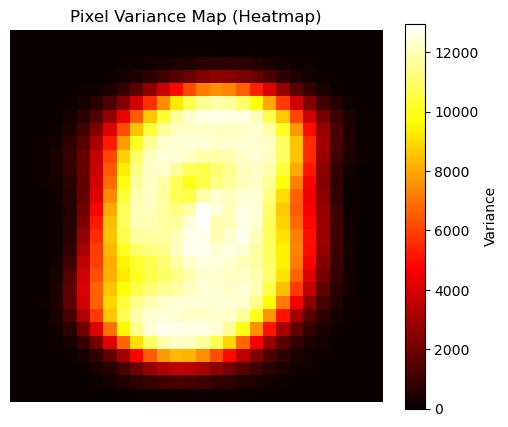

In [13]:
# 14. Visualize the variance map as a 28x28 image.

variance_map = variances.values.reshape(28, 28)

plt.figure(figsize=(6, 5))
plt.imshow(variance_map, cmap='hot')
plt.colorbar(label='Variance')
plt.title('Pixel Variance Map (Heatmap)')
plt.axis('off')
plt.show()

In [14]:
# 15. Identify how many pixels have very low variance (< threshold).
# Let's set a threshold, e.g., 0.1 * max_variance, or a fixed number like 100.

threshold = 100  # Arbitrary threshold given pixel values range 0-255
low_var_count = (variances < threshold).sum()

print(f"Number of pixels with variance < {threshold}: {low_var_count} (out of 784)")

Number of pixels with variance < 100: 263 (out of 784)


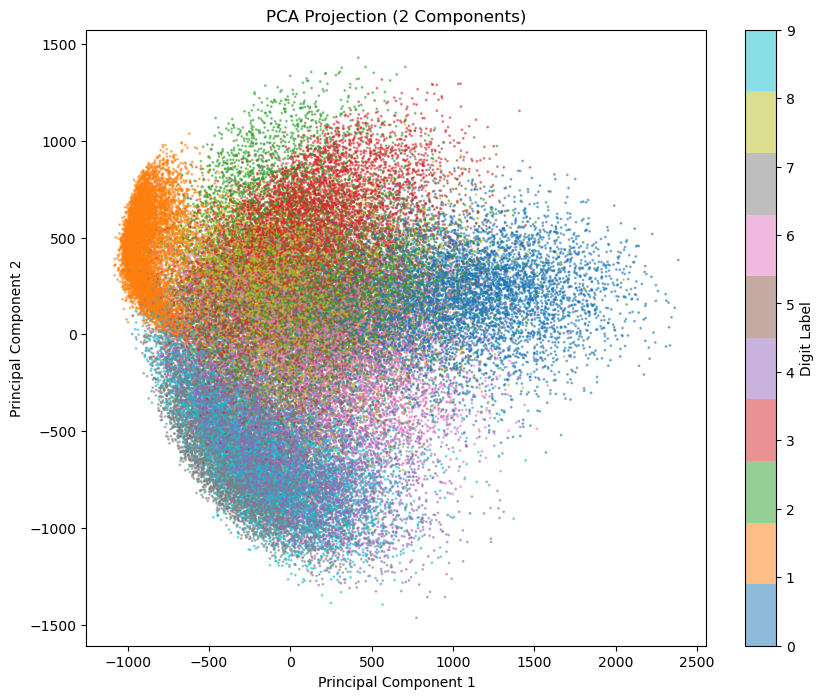

In [15]:
# 16. Reduce dataset to 2 principal components and create a scatter plot colored by digit class.

from sklearn.decomposition import PCA

# Using a subset for faster PCA visualization if needed, but MNIST fits in memory.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit Label')
plt.title('PCA Projection (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 17. Do the digit classes appear separable in 2D PCA space?

**Answer:**
Not entirely. While some clusters (like digit 0 and digit 1) appear somewhat distinct, there is significant overlap between many classes (e.g., 4, 9, and 7 often overlap, as do 3, 5, and 8). Linear PCA in 2D is insufficient to perfectly separate the complex, non-linear manifold of handwritten digits.

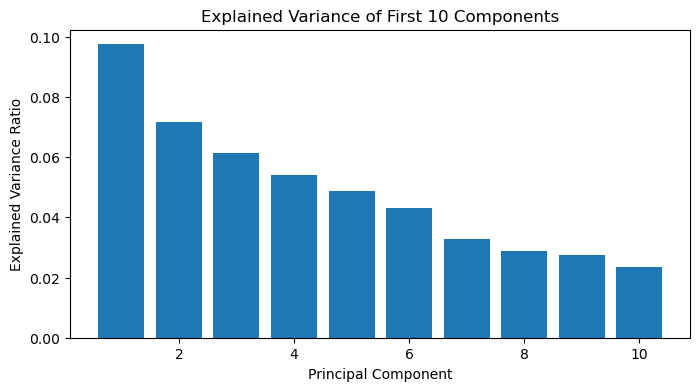

Variance ratios: [0.09746116 0.07155445 0.06149531 0.05403385 0.04888934 0.04305227
 0.03278262 0.02889642 0.02758364 0.0234214 ]


In [16]:
# 18. Compare explained variance of first 10 principal components.

pca_10 = PCA(n_components=10)
pca_10.fit(X)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca_10.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance of First 10 Components')
plt.show()

print("Variance ratios:", pca_10.explained_variance_ratio_)

In [17]:
# 19. Apply PCA and determine how many components explain 90% variance.

pca_full = PCA(n_components=0.90)
X_pca_90 = pca_full.fit_transform(X)

n_components_90 = pca_full.n_components_
print(f"Number of components to explain 90% variance: {n_components_90}")

Number of components to explain 90% variance: 87


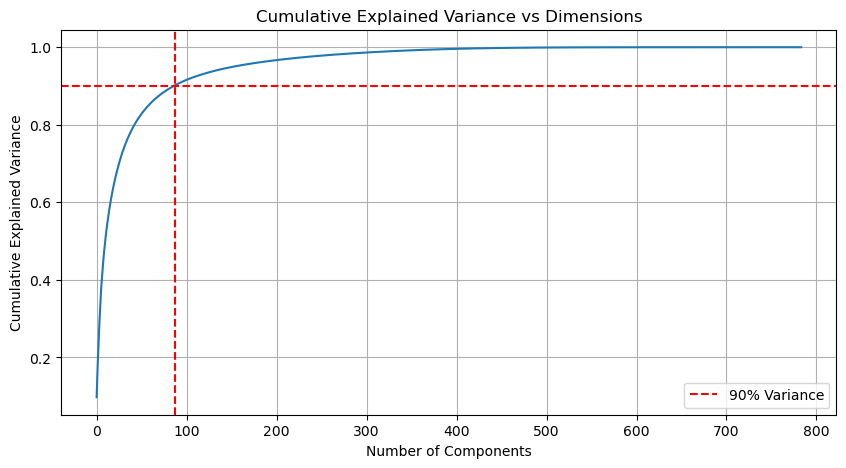

In [18]:
# 20. Plot cumulative explained variance vs number of components.

pca_all = PCA().fit(X)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_all.explained_variance_ratio_))
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.axvline(x=n_components_90, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Dimensions')
plt.legend()
plt.grid()
plt.show()

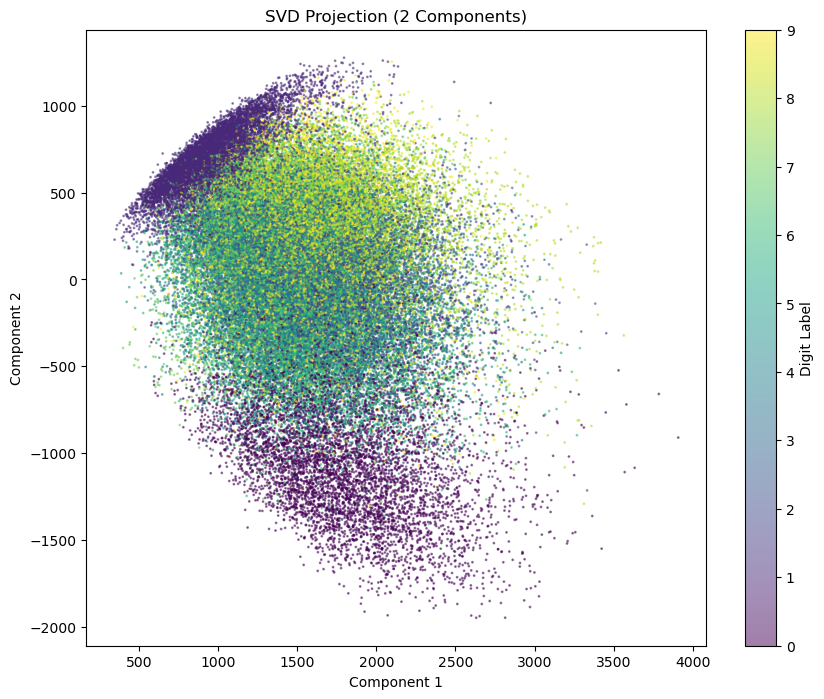

In [19]:
# 21. Reduce dataset to 2 SVD components and create a scatter plot colored by digit class.
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y, cmap='viridis', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit Label')
plt.title('SVD Projection (2 Components)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

### 22. Do the digit classes appear separable in 2D SVD space?

**Answer:**
Similar to PCA, the classes are not fully separable in 2D SVD space. While there is some grouping of similar digits, the overlap remains high. SVD and PCA are mathematically very similar (SVD is often used to compute PCA), so their visual results in 2D are nearly identical.

### 23. What needs to be done to visualize the images?

**Answer:**
The raw data comes in a flattened format (1D array of 784 pixels). To visualize them as images, we must **reshape** the 1D arrays back into 2D matrices of shape **(28, 28)**. This reconstructs the spatial grid of the pixels.

### 24. Why is feature scaling important for MNIST?

**Answer:**
Feature scaling (e.g., dividing by 255 to get values between 0 and 1) is important because:
1. **Convergence Speed:** Optimization algorithms (like Gradient Descent used in Neural Networks) converge much faster on scaled data.
2. **Algorithm Sensitivity:** Distance-based algorithms (like KNN or SVM) are sensitive to the scale of input features. While MNIST pixels share the same scale (0-255), scaling ensures numerical stability and prevents large values from dominating calculations in certain loss functions.
3. **Regularization:** If using regularization (L1/L2), scaling ensures that penalties are applied uniformly.

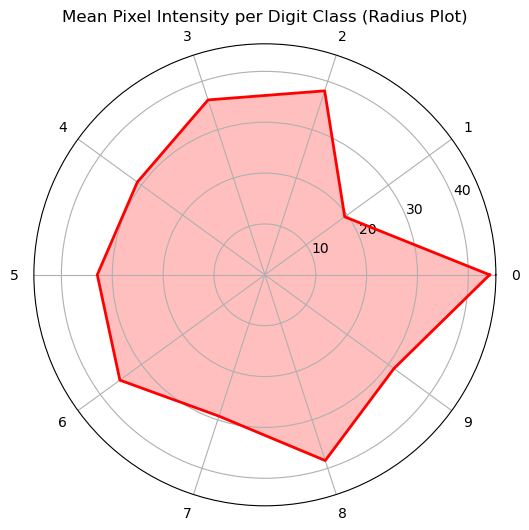

This plot shows which digits use the most 'ink' (highest average intensity) on average.


In [20]:
# 25. Give a radius plot connecting all mean pixel of different classes.
# Interpreting this as a Radar Chart (Spider Plot) comparing the average pixel INTENSITY of each class.

# Calculate mean intensity scalar for each class
class_means = X.groupby(y).mean().mean(axis=1)

labels = class_means.index.astype(str)
stats = class_means.values

# Close the plot loop
stats = np.concatenate((stats, [stats[0]]))
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, stats, color='red', alpha=0.25)
ax.plot(angles, stats, color='red', linewidth=2)

# Fix axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Mean Pixel Intensity per Digit Class (Radius Plot)")
plt.show()

print("This plot shows which digits use the most 'ink' (highest average intensity) on average.")